# Examen tercer parcial de Machine Learning
<img src="img/Logo.jpeg" alt="logo itq" width="200">

**Nombre:** *Evelyn Lascano*<br>
**Fecha:** *12/06/2026*

## Convocatoria 1 - Proyecto 1

## Célula sana - Proceso

#### 0) Cargar una de las imágenes histológicas

In [126]:
# Utilizar la librería skimage.io para leer la imagen 'histo_1.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

Dimensiones de la imagen original: (1024, 1024, 3)
Rango de píxeles normalizados: 0.0 a 1.0


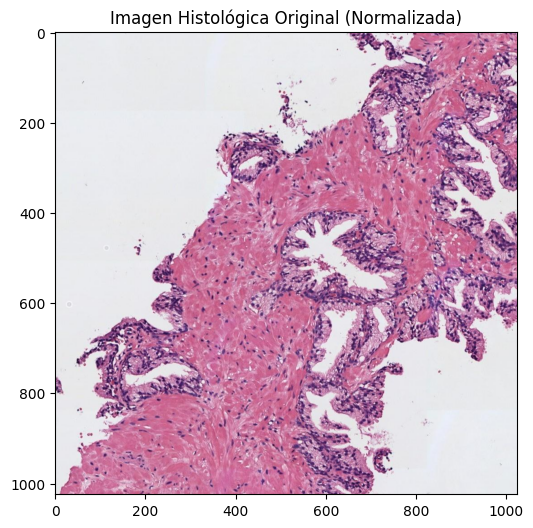

In [127]:
#Cargar una de las imágenes histológicas
import matplotlib.pyplot as plt
import cv2
import numpy as np
from skimage import io

# Leer la imagen histológica en formato RGB (Reemplaza 'histo_1.jpg' por el nombre real de tu archivo)
img = io.imread('images/histo_1.jpg')

# Normalizar la imagen para que los píxeles pasen del rango [0, 255] al rango [0, 1]
img_norm = img.astype(np.float32) / 255.0

# Imprimir las dimensiones para verificar que se cargó correctamente
print("Dimensiones de la imagen original:", img.shape)
print("Rango de píxeles normalizados:", img_norm.min(), "a", img_norm.max())

# Visualizar la imagen cargada
plt.figure(figsize=(6, 6))
plt.imshow(img_norm)
plt.title("Imagen Histológica Original (Normalizada)")
plt.axis('on') # Dejamos los ejes visibles para reconocer las coordenadas de la matriz si es necesario
plt.show()

* io.imread: Carga la imagen manteniendo el espacio de color nativo de Python (RGB), que es el que pide la guía.

* Normalización (/ 255.0): Transforma los valores enteros de 8 bits a valores decimales continuos entre 0 y 1. Esto es un estándar matemático clave en procesamiento avanzado de imágenes antes de aplicar ciertas transformaciones.

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [128]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

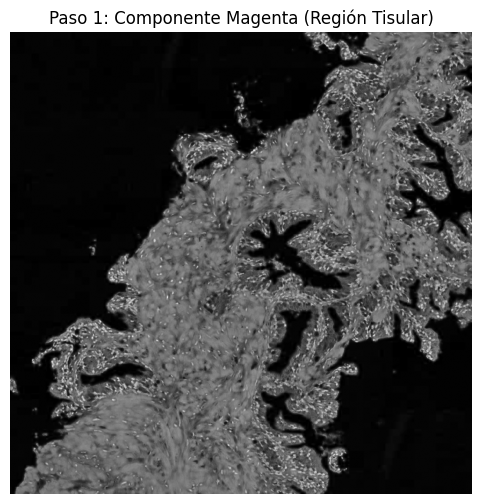

In [129]:
# 1.1) Extraer los canales individuales R, G y B de la imagen original
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

# 1.2) Calcular el canal "Key" o Negro (K) del espacio CMYK
K = 1 - np.max(img, axis=2)

# 1.3) Calcular el canal Magenta (M) usando la fórmula de conversión matemática
# Se añade un valor muy pequeño (1e-10) en el divisor para evitar errores si K vale 1
M = (1 - G - K) / (1 - K + 1e-10)

# 1.4) Visualizar el canal Magenta en escala de grises
plt.figure(figsize=(6, 6))
plt.imshow(M, cmap="gray")
plt.title("Paso 1: Componente Magenta (Región Tisular)")
plt.axis("off")
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [130]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

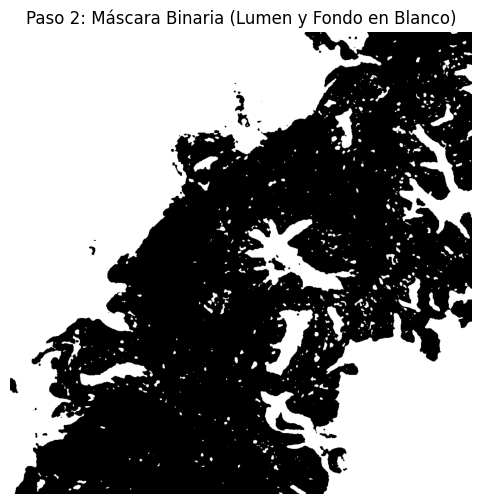

In [131]:
# 2.1) Aplicar un filtro Gaussiano de tamaño 5x5 para suavizar el ruido
M_blur = cv2.GaussianBlur(M, (5, 5), 0)

# 2.2) Convertir la imagen de rango decimal [0.0, 1.0] a enteros de 8 bits [0, 255]
M_uint8 = (M_blur * 255).astype(np.uint8)

# 2.3) Aplicar el método de Otsu de forma inversa (THRESH_BINARY_INV)
# Esto hace que las zonas oscuras (lumen y fondo) sean 1s y el tejido sea 0
_, mask = cv2.threshold(M_uint8, 0, 1, cv2.THRESH_OTSU + cv2.THRESH_BINARY_INV)

# 2.4) Visualizar la máscara binaria resultante en pantalla
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Paso 2: Máscara Binaria (Lumen y Fondo en Blanco)")
plt.axis("off")
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [132]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

C:\Users\Genar\AppData\Local\Temp\ipykernel_18024\3698543075.py:7: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_clean_bool = remove_small_objects(mask_bool, min_size=300)


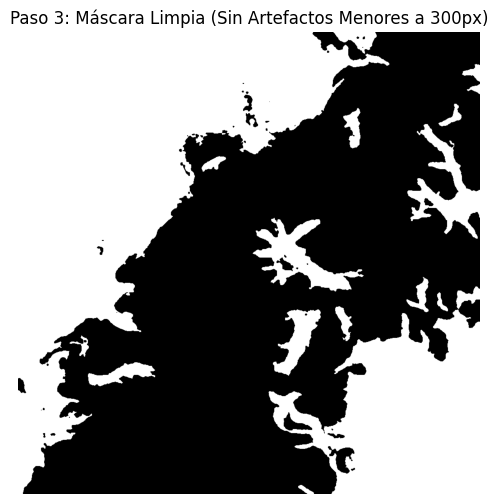

In [133]:
from skimage.morphology import remove_small_objects

# 3.1) Convertir la máscara a tipo booleano (True/False) ya que la función lo exige
mask_bool = mask.astype(bool)

# 3.2) Eliminar los objetos blancos cuyo tamaño sea menor a 300 píxeles
mask_clean_bool = remove_small_objects(mask_bool, min_size=300)

# 3.3) Convertir la máscara limpia de vuelta a números enteros (0 y 1)
mask_clean = mask_clean_bool.astype(np.uint8)

# 3.4) Visualizar la máscara resultante ya limpia en la pantalla
plt.figure(figsize=(6, 6))
plt.imshow(mask_clean, cmap="gray")
plt.title("Paso 3: Máscara Limpia (Sin Artefactos Menores a 300px)")
plt.axis("off")
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [134]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

-> Semillas generadas automáticamente:
   Semilla 1 (Fondo Exterior): (0, 0)
   Semilla 2 (Tejido/Estroma): (np.int64(587), np.int64(573))


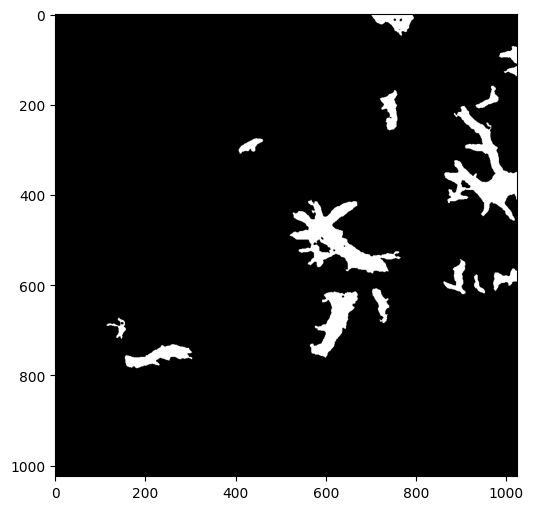

In [135]:
# 4.1) Crear una copia de la máscara limpia del paso anterior
mask_flood = mask_clean.copy()

# Aseguramos que la máscara esté en formato de 8 bits (0 a 255) para evitar errores con OpenCV
if mask_flood.max() == 1:
    mask_flood = mask_flood * 255

# 4.2) SELECCIÓN AUTOMÁTICA DE LAS DOS SEMILLAS (Cumpliendo la pista del profesor)
# Semilla 1: Esquina superior izquierda (0,0) para identificar e inundar el fondo exterior
semilla_fondo = (0, 0)

# Semilla 2: AUTOMÁTICA Y SEGURA PARA EL TEJIDO (ESTROMA)
puntos_tejido = np.argwhere(mask_flood == 0)
semilla_tejido = tuple(puntos_tejido[len(puntos_tejido) // 2][::-1])

print(f"-> Semillas generadas automáticamente:")
print(f"   Semilla 1 (Fondo Exterior): {semilla_fondo}")
print(f"   Semilla 2 (Tejido/Estroma): {semilla_tejido}")

# 4.3) ALGORITMO DE EXPANSIÓN POR CRECIMIENTO DE REGIONES (Region Growing)
h, w = mask_flood.shape
r_mask_1 = np.zeros((h + 2, w + 2), np.uint8)
r_mask_2 = np.zeros((h + 2, w + 2), np.uint8)

# PRIMERA INUNDACIÓN: Pintamos el fondo exterior con un gris temporal (valor 128)
cv2.floodFill(mask_flood, r_mask_1, semilla_fondo, 128)

# SEGUNDA INUNDACIÓN: Desde la semilla del tejido, expandimos el negro absoluto (0)
cv2.floodFill(mask_flood, r_mask_2, semilla_tejido, 0)

# POST-PROCESADO: Dejar únicamente lúmenes en blanco (255) y el resto en negro (0)
mask_flood[mask_flood == 128] = 0
mask_flood[mask_flood == 255] = 255

# --- ELIMINACIÓN DE RUIDO Y LÚMENES DE LOS BORDES INVASIVOS ---
# Encontramos todos los objetos blancos aislados que quedaron en la máscara
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_flood, connectivity=8)

# Creamos una nueva máscara vacía para guardar solo los lúmenes internos perfectos
mask_clean_lumenes = np.zeros_like(mask_flood)

# Definimos el tamaño mínimo de píxeles para ignorar ruido pequeño
area_minima = 150 

for i in range(1, num_labels): # Empezamos desde 1 para ignorar el fondo negro
    area = stats[i, cv2.CC_STAT_AREA]
    
    # Obtenemos las coordenadas de la caja que encierra al objeto (Bounding Box)
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    ancho = stats[i, cv2.CC_STAT_WIDTH]
    alto = stats[i, cv2.CC_STAT_HEIGHT]
    
    # CONDICIÓN CORREGIDA: Filtramos únicamente los bordes que traen ruido invasivo (Izquierdo e Inferior)
    # De esta manera protegemos la esquina superior derecha para que no se borre su lumen.
    borde_invasivo = (x == 0) or (y + alto >= h)
    
    # SI el objeto NO pertenece a un borde invasivo Y cumple con el tamaño mínimo, lo dejamos
    if not borde_invasivo and area >= area_minima:
        mask_clean_lumenes[labels == i] = 255

# Guardamos el resultado final limpio de vuelta en mask_flood
mask_flood = mask_clean_lumenes

# 4.4) Visualizar la máscara resultante conteniendo estrictamente los lúmenes internos principales
plt.figure(figsize=(6, 6))
plt.imshow(mask_flood, cmap="gray")

#### 5) Rellenar los objetos de los lúmenes

In [136]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

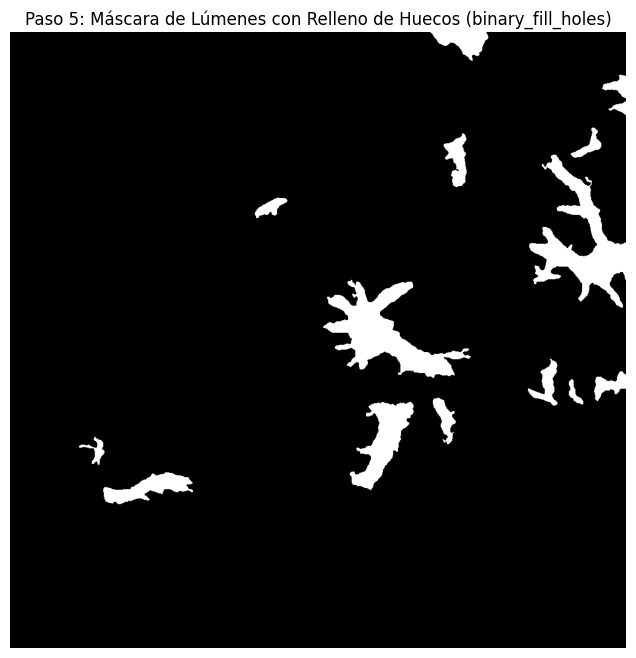

In [137]:
from scipy.ndimage import binary_fill_holes

# 1. Rellenar los lúmenes eliminando huecos internos
mask_filled_lumenes = binary_fill_holes(mask_clean_lumenes)

# 2. Visualizar el resultado de la máscara rellena
plt.figure(figsize=(8, 8))
plt.imshow(mask_filled_lumenes, cmap='gray')
plt.title('Paso 5: Máscara de Lúmenes con Relleno de Huecos (binary_fill_holes)')
plt.axis('off')
plt.show()

¿Qué se logró aquí?
Se logró eliminar cualquier imperfección o vacío interno dentro de las estructuras de los lúmenes seleccionados. Al rellenar estos huecos, las figuras dejan de ser simples siluetas o anillos y se convierten en masas blancas sólidas y homogéneas. Esto es crucial para la materia de IA y visión por computadora, ya que si dejáramos huecos negros adentro, los cálculos matemáticos del área real y del perímetro en los pasos finales saldrían erróneos o sesgados.

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [138]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

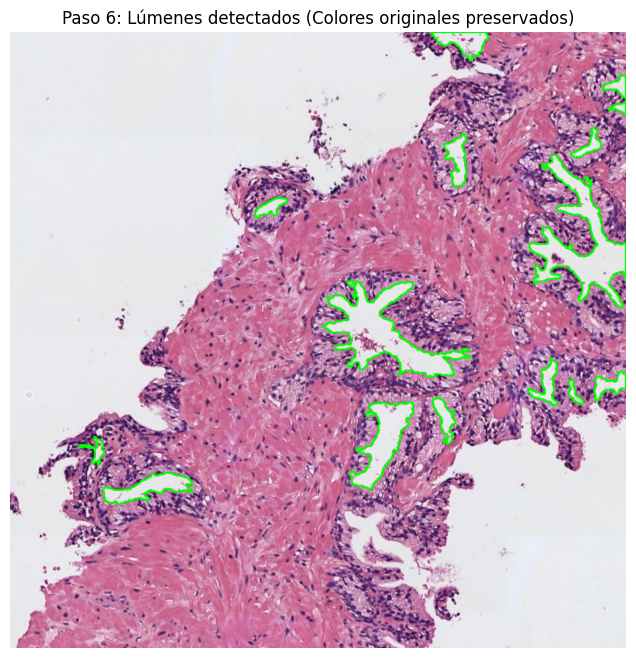

In [139]:
# 6.1) Detectar los contornos
contornos, _ = cv2.findContours(mask_flood, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 6.2) Preparar la imagen para dibujar
# Usamos tu variable original 'img'
imagen_dibujo = img.copy()

# 6.3) Dibujar los contornos
# Como 'img' ya es RGB, el verde puro sigue siendo (0, 255, 0)
cv2.drawContours(imagen_dibujo, contornos, -1, (0, 255, 0), thickness=2)

# 6.4) Visualizar (Ya está en formato RGB, así que imshow la mostrará perfecto)
plt.figure(figsize=(8, 8))
plt.imshow(imagen_dibujo)
plt.title("Paso 6: Lúmenes detectados (Colores originales preservados)")
plt.axis("off")
plt.show()

#### 7) Identificar y cropear el lumen más grande

In [140]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

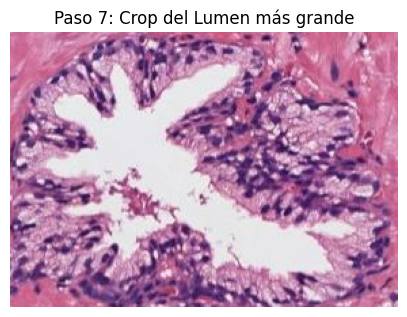

In [141]:
# 7.1) En lugar de usar la lista de contornos, analizamos directamente 
# la máscara limpia del Paso 4 donde solo quedaron los lúmenes reales.
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_flood, connectivity=8)

# 7.2) Buscamos el índice del componente con mayor área (ignorando el fondo que es el label 0)
# stats[1:, cv2.CC_STAT_AREA] toma todas las áreas menos la del fondo
areas = stats[1:, cv2.CC_STAT_AREA]
max_idx = np.argmax(areas) + 1  # +1 porque el índice 0 es el fondo

# 7.3) Obtenemos las coordenadas del lumen ganador
x = stats[max_idx, cv2.CC_STAT_LEFT]
y = stats[max_idx, cv2.CC_STAT_TOP]
ancho = stats[max_idx, cv2.CC_STAT_WIDTH]
alto = stats[max_idx, cv2.CC_STAT_HEIGHT]

# 7.4) Recortamos sobre la imagen original 'img'
# Agregamos un pequeño margen para ver un poco de tejido alrededor
margen = 20
y1 = max(0, y - margen)
y2 = min(img.shape[0], y + alto + margen)
x1 = max(0, x - margen)
x2 = min(img.shape[1], x + ancho + margen)

crop_lumen = img[y1:y2, x1:x2]

# 7.5) Visualización
plt.figure(figsize=(5, 5))
plt.imshow(crop_lumen)
plt.title("Paso 7: Crop del Lumen más grande")
plt.axis("off")
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [142]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [143]:
from skimage.measure import label, regionprops

# 8.1)Usamos la máscara segmentada del paso anterior (mask_flood)
# Recortamos la máscara usando las mismas coordenadas x, y, w, h del paso 7
crop_mask = mask_flood[y : y + h, x : x + w].astype(np.uint8)

# 8.2) Asegurar que la estructura esté etiquetada
# Esto convierte el recorte binario en un objeto que skimage puede medir
crop_label = label(crop_mask)

# 8.3) Extraer las propiedades morfológicas
propiedades = regionprops(crop_label)

if len(propiedades) > 0:
    # Seleccionamos el objeto (si hubiera varios, tomamos el de mayor área)
    prop = max(propiedades, key=lambda p: p.area)
    
    # 8.4) Cálculo de las características
    area           = np.round(prop.area, 4)
    area_bb        = np.round(prop.bbox_area, 4)
    area_conv      = np.round(prop.convex_area, 4)
    excentricidad  = np.round(prop.eccentricity, 4)
    diametro_eq    = np.round(prop.equivalent_diameter_area, 4)
    extension      = np.round(prop.extent, 4)
    diametro_feret = np.round(prop.feret_diameter_max, 4)
    eje_mayor      = np.round(prop.axis_major_length, 4)
    eje_menor      = np.round(prop.axis_minor_length, 4)
    orientacion    = np.round(prop.orientation, 4)
    perimetro      = np.round(prop.perimeter, 4)
    solidez        = np.round(prop.solidity, 4)
    
    # 13) Cálculo preciso de Compacidad
    compacidad = np.round((4 * np.pi * area) / (perimetro**2), 4) if perimetro > 0 else 0.0

    # 8.5) Reporte final
    print("REPORTE DE CARACTERÍSTICAS GEOMÉTRICAS ")
    print(f"1) Área: {area}")
    print(f"2) Área de la bounding box: {area_bb}")
    print(f"3) Área convexa: {area_conv}")
    print(f"4) Excentricidad: {excentricidad}")
    print(f"5) Diámetro equivalente: {diametro_eq}")
    print(f"6) Extensión: {extension}")
    print(f"7) Diámetro Feret: {diametro_feret}")
    print(f"8) Longitud del eje mayor: {eje_mayor}")
    print(f"9) Longitud del eje menor: {eje_menor}")
    print(f"10) Orientación: {orientacion}")
    print(f"11) Perímetro: {perimetro}")
    print(f"12) Solidez: {solidez}")
    print(f"13) Compacidad: {compacidad}")
    print("====================================================")
else:
    print("Error: No se detectó ninguna estructura sólida dentro del recorte.")

REPORTE DE CARACTERÍSTICAS GEOMÉTRICAS 
1) Área: 13556.0
2) Área de la bounding box: 40098.0
3) Área convexa: 29267.0
4) Excentricidad: 0.8516
5) Diámetro equivalente: 131.3775
6) Extensión: 0.3381
7) Diámetro Feret: 259.0772
8) Longitud del eje mayor: 242.934
9) Longitud del eje menor: 127.3307
10) Orientación: 0.9985
11) Perímetro: 1412.2073
12) Solidez: 0.4632
13) Compacidad: 0.0854


C:\Users\Genar\AppData\Local\Temp\ipykernel_18024\2050708651.py:20: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  area_bb        = np.round(prop.bbox_area, 4)
C:\Users\Genar\AppData\Local\Temp\ipykernel_18024\2050708651.py:21: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  area_conv      = np.round(prop.convex_area, 4)


## Célula cancerígena

#### 0) Cargar una de las imágenes histológicas

Dimensiones de la imagen original: (1024, 1024, 3)
Rango de píxeles normalizados: 0.0 a 1.0


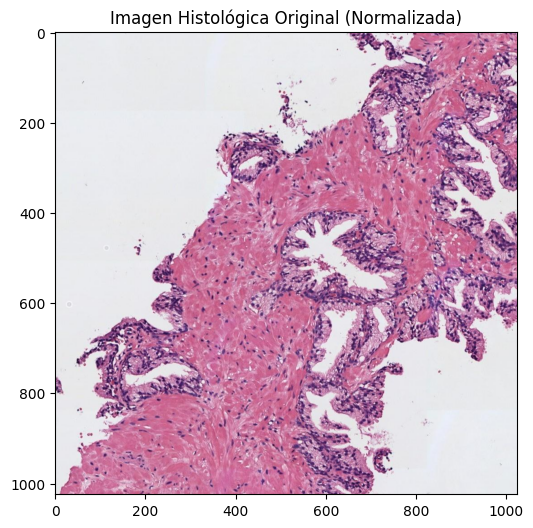

In [155]:
# Leer la imagen histológica en formato RGB (Reemplaza 'histo_1.jpg' por el nombre real de tu archivo)
img2 = io.imread('images/histo_2.jpg')

# Normalizar la imagen para que los píxeles pasen del rango [0, 255] al rango [0, 1]
img_norm = img.astype(np.float32) / 255.0

# Imprimir las dimensiones para verificar que se cargó correctamente
print("Dimensiones de la imagen original:", img.shape)
print("Rango de píxeles normalizados:", img_norm.min(), "a", img_norm.max())

# Visualizar la imagen cargada
plt.figure(figsize=(6, 6))
plt.imshow(img_norm)
plt.title("Imagen Histológica Original (Normalizada)")
plt.axis('on') # Dejamos los ejes visibles para reconocer las coordenadas de la matriz si es necesario
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

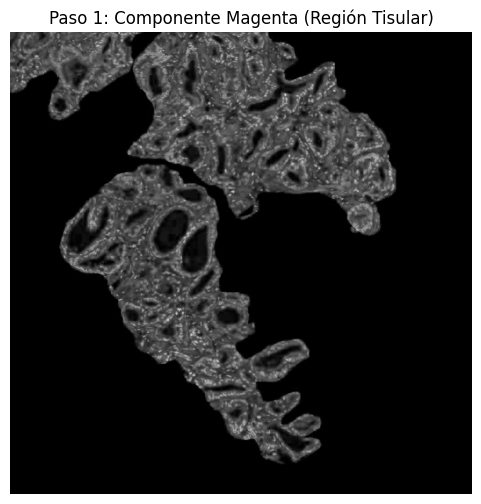

In [156]:
# 1.1) Extraer los canales individuales R, G y B de la imagen original
R = img2[:, :, 0]
G = img2[:, :, 1]
B = img2[:, :, 2]

# 1.2) Calcular el canal "Key" o Negro (K) del espacio CMYK
K = 1 - np.max(img2, axis=2)

# 1.3) Calcular el canal Magenta (M) usando la fórmula de conversión matemática
# Se añade un valor muy pequeño (1e-10) en el divisor para evitar errores si K vale 1
M = (1 - G - K) / (1 - K + 1e-10)

# 1.4) Visualizar el canal Magenta en escala de grises
plt.figure(figsize=(6, 6))
plt.imshow(M, cmap="gray")
plt.title("Paso 1: Componente Magenta (Región Tisular)")
plt.axis("off")
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

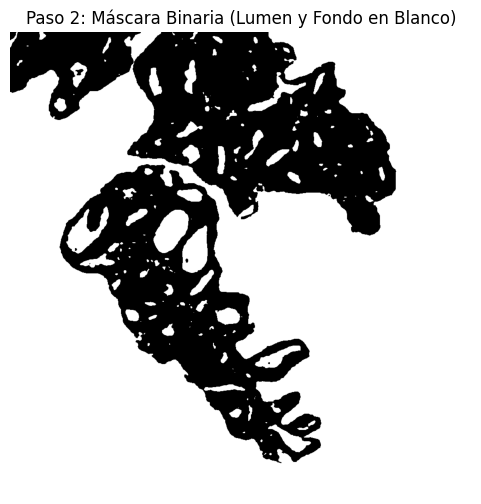

In [157]:
# 2.1) Aplicar un filtro Gaussiano de tamaño 5x5 para suavizar el ruido
M_blur = cv2.GaussianBlur(M, (5, 5), 0)

# 2.2) Convertir la imagen de rango decimal [0.0, 1.0] a enteros de 8 bits [0, 255]
M_uint8 = (M_blur * 255).astype(np.uint8)

# 2.3) Aplicar el método de Otsu de forma inversa (THRESH_BINARY_INV)
# Esto hace que las zonas oscuras (lumen y fondo) sean 1s y el tejido sea 0
_, mask = cv2.threshold(M_uint8, 0, 1, cv2.THRESH_OTSU + cv2.THRESH_BINARY_INV)

# 2.4) Visualizar la máscara binaria resultante en pantalla
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Paso 2: Máscara Binaria (Lumen y Fondo en Blanco)")
plt.axis("off")
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

C:\Users\Genar\AppData\Local\Temp\ipykernel_18024\3698543075.py:7: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_clean_bool = remove_small_objects(mask_bool, min_size=300)


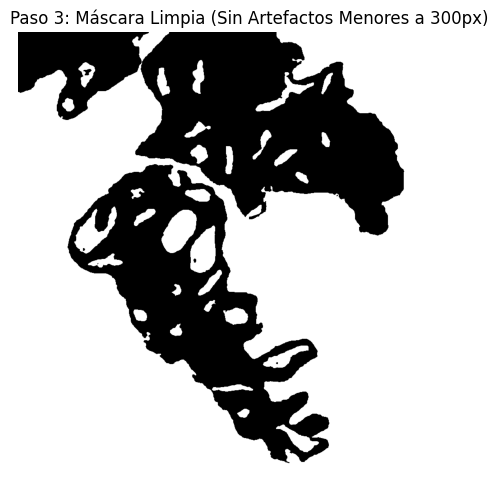

In [158]:
from skimage.morphology import remove_small_objects

# 3.1) Convertir la máscara a tipo booleano (True/False) ya que la función lo exige
mask_bool = mask.astype(bool)

# 3.2) Eliminar los objetos blancos cuyo tamaño sea menor a 300 píxeles
mask_clean_bool = remove_small_objects(mask_bool, min_size=300)

# 3.3) Convertir la máscara limpia de vuelta a números enteros (0 y 1)
mask_clean = mask_clean_bool.astype(np.uint8)

# 3.4) Visualizar la máscara resultante ya limpia en la pantalla
plt.figure(figsize=(6, 6))
plt.imshow(mask_clean, cmap="gray")
plt.title("Paso 3: Máscara Limpia (Sin Artefactos Menores a 300px)")
plt.axis("off")
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

-> Semillas generadas automáticamente:
   Semilla 1 (Fondo Exterior): (0, 0)
   Semilla 2 (Tejido/Estroma): (np.int64(336), np.int64(310))


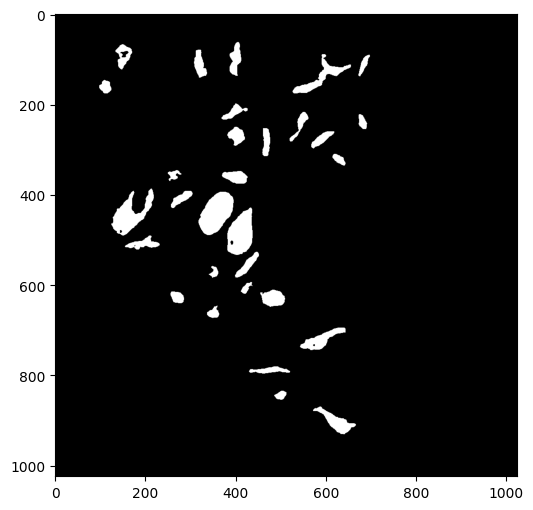

In [159]:
# 4.1) Crear una copia de la máscara limpia del paso anterior
mask_flood = mask_clean.copy()

# Aseguramos que la máscara esté en formato de 8 bits (0 a 255) para evitar errores con OpenCV
if mask_flood.max() == 1:
    mask_flood = mask_flood * 255

# 4.2) SELECCIÓN AUTOMÁTICA DE LAS DOS SEMILLAS (Cumpliendo la pista del profesor)
# Semilla 1: Esquina superior izquierda (0,0) para identificar e inundar el fondo exterior
semilla_fondo = (0, 0)

# Semilla 2: AUTOMÁTICA Y SEGURA PARA EL TEJIDO (ESTROMA)
puntos_tejido = np.argwhere(mask_flood == 0)
semilla_tejido = tuple(puntos_tejido[len(puntos_tejido) // 2][::-1])

print(f"-> Semillas generadas automáticamente:")
print(f"   Semilla 1 (Fondo Exterior): {semilla_fondo}")
print(f"   Semilla 2 (Tejido/Estroma): {semilla_tejido}")

# 4.3) ALGORITMO DE EXPANSIÓN POR CRECIMIENTO DE REGIONES (Region Growing)
h, w = mask_flood.shape
r_mask_1 = np.zeros((h + 2, w + 2), np.uint8)
r_mask_2 = np.zeros((h + 2, w + 2), np.uint8)

# PRIMERA INUNDACIÓN: Pintamos el fondo exterior con un gris temporal (valor 128)
cv2.floodFill(mask_flood, r_mask_1, semilla_fondo, 128)

# SEGUNDA INUNDACIÓN: Desde la semilla del tejido, expandimos el negro absoluto (0)
cv2.floodFill(mask_flood, r_mask_2, semilla_tejido, 0)

# POST-PROCESADO: Dejar únicamente lúmenes en blanco (255) y el resto en negro (0)
mask_flood[mask_flood == 128] = 0
mask_flood[mask_flood == 255] = 255

# --- ELIMINACIÓN DE RUIDO Y LÚMENES DE LOS BORDES INVASIVOS ---
# Encontramos todos los objetos blancos aislados que quedaron en la máscara
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_flood, connectivity=8)

# Creamos una nueva máscara vacía para guardar solo los lúmenes internos perfectos
mask_clean_lumenes = np.zeros_like(mask_flood)

# Definimos el tamaño mínimo de píxeles para ignorar ruido pequeño
area_minima = 150 

for i in range(1, num_labels): # Empezamos desde 1 para ignorar el fondo negro
    area = stats[i, cv2.CC_STAT_AREA]
    
    # Obtenemos las coordenadas de la caja que encierra al objeto (Bounding Box)
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    ancho = stats[i, cv2.CC_STAT_WIDTH]
    alto = stats[i, cv2.CC_STAT_HEIGHT]
    
    # CONDICIÓN CORREGIDA: Filtramos únicamente los bordes que traen ruido invasivo (Izquierdo e Inferior)
    # De esta manera protegemos la esquina superior derecha para que no se borre su lumen.
    borde_invasivo = (x == 0) or (y + alto >= h)
    
    # SI el objeto NO pertenece a un borde invasivo Y cumple con el tamaño mínimo, lo dejamos
    if not borde_invasivo and area >= area_minima:
        mask_clean_lumenes[labels == i] = 255

# Guardamos el resultado final limpio de vuelta en mask_flood
mask_flood = mask_clean_lumenes

# 4.4) Visualizar la máscara resultante conteniendo estrictamente los lúmenes internos principales
plt.figure(figsize=(6, 6))
plt.imshow(mask_flood, cmap="gray")

#### 5) Rellenar los objetos de los lúmenes

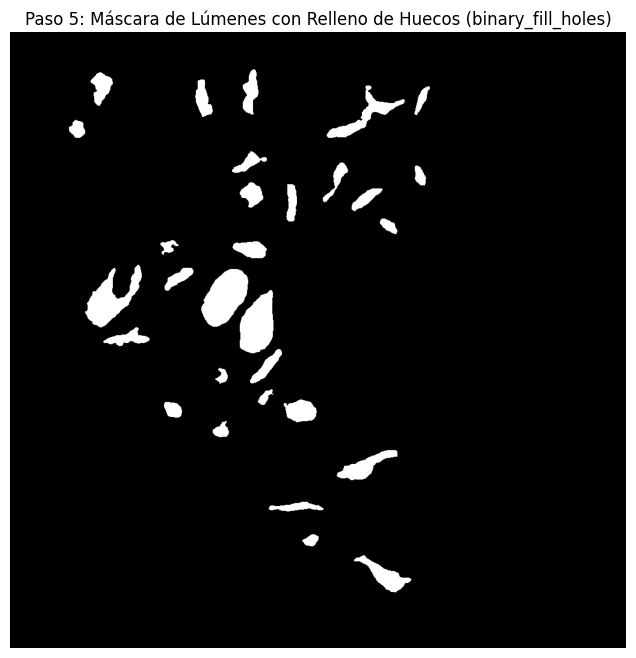

In [160]:
from scipy.ndimage import binary_fill_holes

# 1. Rellenar los lúmenes eliminando huecos internos
mask_filled_lumenes = binary_fill_holes(mask_clean_lumenes)

# 2. Visualizar el resultado de la máscara rellena
plt.figure(figsize=(8, 8))
plt.imshow(mask_filled_lumenes, cmap='gray')
plt.title('Paso 5: Máscara de Lúmenes con Relleno de Huecos (binary_fill_holes)')
plt.axis('off')
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

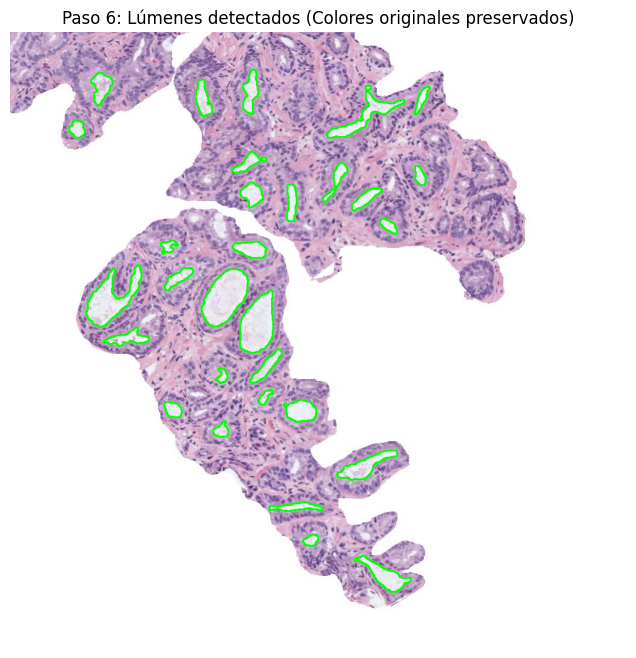

In [161]:
# 6.1) Detectar los contornos
contornos, _ = cv2.findContours(mask_flood, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 6.2) Preparar la imagen para dibujar
# Usamos tu variable original 'img'
imagen_dibujo = img2.copy()

# 6.3) Dibujar los contornos
# Como 'img' ya es RGB, el verde puro sigue siendo (0, 255, 0)
cv2.drawContours(imagen_dibujo, contornos, -1, (0, 255, 0), thickness=2)

# 6.4) Visualizar (Ya está en formato RGB, así que imshow la mostrará perfecto)
plt.figure(figsize=(8, 8))
plt.imshow(imagen_dibujo)
plt.title("Paso 6: Lúmenes detectados (Colores originales preservados)")
plt.axis("off")
plt.show()

#### 7) Identificar y cropear el lumen más grande

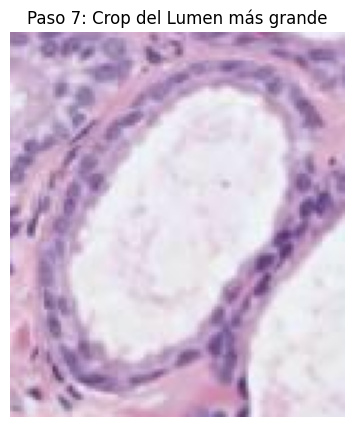

In [162]:
# 7.1) En lugar de usar la lista de contornos, analizamos directamente 
# la máscara limpia del Paso 4 donde solo quedaron los lúmenes reales.
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_flood, connectivity=8)

# 7.2) Buscamos el índice del componente con mayor área (ignorando el fondo que es el label 0)
# stats[1:, cv2.CC_STAT_AREA] toma todas las áreas menos la del fondo
areas = stats[1:, cv2.CC_STAT_AREA]
max_idx = np.argmax(areas) + 1  # +1 porque el índice 0 es el fondo

# 7.3) Obtenemos las coordenadas del lumen ganador
x = stats[max_idx, cv2.CC_STAT_LEFT]
y = stats[max_idx, cv2.CC_STAT_TOP]
ancho = stats[max_idx, cv2.CC_STAT_WIDTH]
alto = stats[max_idx, cv2.CC_STAT_HEIGHT]

# 7.4) Recortamos sobre la imagen original 'img'
# Agregamos un pequeño margen para ver un poco de tejido alrededor
margen = 20
y1 = max(0, y - margen)
y2 = min(img2.shape[0], y + alto + margen)
x1 = max(0, x - margen)
x2 = min(img2.shape[1], x + ancho + margen)

crop_lumen = img2[y1:y2, x1:x2]

# 7.5) Visualización
plt.figure(figsize=(6, 5))
plt.imshow(crop_lumen)
plt.title("Paso 7: Crop del Lumen más grande")
plt.axis("off")
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [163]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [164]:
# from skimage.measure import label, regionprops

# # 8.1)Usamos la máscara segmentada del paso anterior (mask_flood)
# # Recortamos la máscara usando las mismas coordenadas x, y, w, h del paso 7
# crop_mask = mask_flood[y : y + h, x : x + w].astype(np.uint8)

# # 8.2) Asegurar que la estructura esté etiquetada
# # Esto convierte el recorte binario en un objeto que skimage puede medir
# crop_label = label(crop_mask)

# # 8.3) Extraer las propiedades morfológicas
# propiedades = regionprops(crop_label)

# if len(propiedades) > 0:
#     # Seleccionamos el objeto (si hubiera varios, tomamos el de mayor área)
#     prop = max(propiedades, key=lambda p: p.area)
    
#     # 8.4) Cálculo de las características
#     area           = np.round(prop.area, 4)
#     area_bb        = np.round(prop.bbox_area, 4)
#     area_conv      = np.round(prop.convex_area, 4)
#     excentricidad  = np.round(prop.eccentricity, 4)
#     diametro_eq    = np.round(prop.equivalent_diameter_area, 4)
#     extension      = np.round(prop.extent, 4)
#     diametro_feret = np.round(prop.feret_diameter_max, 4)
#     eje_mayor      = np.round(prop.axis_major_length, 4)
#     eje_menor      = np.round(prop.axis_minor_length, 4)
#     orientacion    = np.round(prop.orientation, 4)
#     perimetro      = np.round(prop.perimeter, 4)
#     solidez        = np.round(prop.solidity, 4)
    
#     # 13) Cálculo preciso de Compacidad
#     compacidad = np.round((4 * np.pi * area) / (perimetro**2), 4) if perimetro > 0 else 0.0

#     # 8.5) Reporte final
#     print("REPORTE DE CARACTERÍSTICAS GEOMÉTRICAS ")
#     print(f"1) Área: {area}")
#     print(f"2) Área de la bounding box: {area_bb}")
#     print(f"3) Área convexa: {area_conv}")
#     print(f"4) Excentricidad: {excentricidad}")
#     print(f"5) Diámetro equivalente: {diametro_eq}")
#     print(f"6) Extensión: {extension}")
#     print(f"7) Diámetro Feret: {diametro_feret}")
#     print(f"8) Longitud del eje mayor: {eje_mayor}")
#     print(f"9) Longitud del eje menor: {eje_menor}")
#     print(f"10) Orientación: {orientacion}")
#     print(f"11) Perímetro: {perimetro}")
#     print(f"12) Solidez: {solidez}")
#     print(f"13) Compacidad: {compacidad}")
#     print("====================================================")
# else:
#     print("Error: No se detectó ninguna estructura sólida dentro del recorte.")

REPORTE DE CARACTERÍSTICAS GEOMÉTRICAS 
1) Área: 4887.0
2) Área de la bounding box: 7488.0
3) Área convexa: 5021.0
4) Excentricidad: 0.8353
5) Diámetro equivalente: 78.8817
6) Extensión: 0.6526
7) Diámetro Feret: 105.6788
8) Longitud del eje mayor: 106.6133
9) Longitud del eje menor: 58.617
10) Orientación: -0.5614
11) Perímetro: 280.3919
12) Solidez: 0.9733
13) Compacidad: 0.7811


C:\Users\Genar\AppData\Local\Temp\ipykernel_18024\2050708651.py:20: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  area_bb        = np.round(prop.bbox_area, 4)
C:\Users\Genar\AppData\Local\Temp\ipykernel_18024\2050708651.py:21: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  area_conv      = np.round(prop.convex_area, 4)
